# Retail Intelligence & Recommendation System using Instacart Data
## Notebook 5: Reorder Prediction

This notebook builds a predictive Machine Learning workflow to determine whether a customer will reorder a product in their next order. We engineer features across customers, products, and user-product interactions, then train and evaluate **Logistic Regression, Random Forest, XGBoost, and LightGBM** models, utilizing SHAP values for model explainability.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix, accuracy_score
import xgboost as xgb
import lightgbm as lgb
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


### 1. Feature Engineering
We build features from the historical `prior` dataset:
- **User Features:** Total orders, average basket size, reorder rate, average order frequency.
- **Product Features:** Total orders, reorder rate, average add-to-cart position.
- **User-Product Features:** Purchase count of this product by user, user reorder rate for this product, order number when user first bought product.

In [2]:
data_dir = Path("../../datasets/instacart_market_ basket")

# Load files and filter to user_id <= 5000
orders = pd.read_csv(data_dir / "orders.csv")
orders = orders[orders['user_id'] <= 5000]
order_ids = set(orders['order_id'])

op_prior = pd.read_csv(data_dir / "order_products__prior.csv")
op_prior = op_prior[op_prior['order_id'].isin(order_ids)]

op_train = pd.read_csv(data_dir / "order_products__train.csv")
op_train = op_train[op_train['order_id'].isin(order_ids)]

# Merge op_prior with orders to compute user and product features
prior_df = op_prior.merge(orders, on='order_id')

print("Engineering User Features...")
user_features = prior_df.groupby('user_id').agg(
    user_total_orders=('order_number', 'max'),
    user_avg_basket_size=('order_id', lambda x: len(x) / x.nunique()),
    user_reorder_rate=('reordered', 'mean'),
    user_avg_days_since_prior=('days_since_prior_order', 'mean')
).reset_index()

print("Engineering Product Features...")
product_features = prior_df.groupby('product_id').agg(
    prod_total_orders=('order_id', 'count'),
    prod_reorder_rate=('reordered', 'mean'),
    prod_avg_add_to_cart=('add_to_cart_order', 'mean')
).reset_index()

print("Engineering User-Product Features...")
user_prod_features = prior_df.groupby(['user_id', 'product_id']).agg(
    up_purchases=('order_id', 'count'),
    up_first_order=('order_number', 'min'),
    up_reorder_rate=('reordered', 'mean')
).reset_index()

print("Features engineered successfully!")

Engineering User Features...
Engineering Product Features...
Engineering User-Product Features...
Features engineered successfully!


### 2. Dataset Construction
We construct the dataset using the `train` set to capture the labels (`reordered` = 0 or 1).

In [3]:
# We will make prediction for the user-product combinations that were purchased in the prior set
# The target label is 1 if it is ordered in the train set, 0 otherwise
train_orders = orders[orders['eval_set'] == 'train']
train_df = op_train.merge(train_orders, on='order_id')

train_labels = train_df[['user_id', 'product_id', 'reordered']].copy()
train_labels.rename(columns={'reordered': 'label'}, inplace=True)

# Merge with user_prod_features
dataset = user_prod_features.merge(train_labels, on=['user_id', 'product_id'], how='left')
dataset['label'] = dataset['label'].fillna(0).astype(int)

# Merge with user_features & product_features
dataset = dataset.merge(user_features, on='user_id', how='left')
dataset = dataset.merge(product_features, on='product_id', how='left')

# Handle NaNs
dataset['user_avg_days_since_prior'] = dataset['user_avg_days_since_prior'].fillna(dataset['user_avg_days_since_prior'].median())
dataset.fillna(0, inplace=True)

print(f"Label distribution:\n{dataset['label'].value_counts(normalize=True)}")
dataset.head()

Label distribution:
label
0    0.935447
1    0.064553
Name: proportion, dtype: float64


,user_id,product_id,up_purchases,up_first_order,up_reorder_rate,label,user_total_orders,user_avg_basket_size,user_reorder_rate,user_avg_days_since_prior,prod_total_orders,prod_reorder_rate,prod_avg_add_to_cart
0,1,196,10,1,0.900000,1,10,5.9,0.694915,20.259259,793,0.765448,4.063052
1,1,10258,9,2,0.888889,1,10,5.9,0.694915,20.259259,53,0.716981,4.094340
2,1,10326,1,5,0.000000,0,10,5.9,0.694915,20.259259,107,0.523364,3.906542
3,1,12427,10,1,0.900000,0,10,5.9,0.694915,20.259259,142,0.676056,5.415493
4,1,13032,3,2,0.666667,1,10,5.9,0.694915,20.259259,55,0.527273,5.200000


### 3. Train-Test Split
We split users into train (80%) and test (20%) to prevent leakage.

In [4]:
unique_users = dataset['user_id'].unique()
train_users, test_users = train_test_split(unique_users, test_size=0.2, random_state=42)

train_data = dataset[dataset['user_id'].isin(train_users)]
test_data = dataset[dataset['user_id'].isin(test_users)]

features = [
    'up_purchases', 'up_first_order', 'up_reorder_rate',
    'user_total_orders', 'user_avg_basket_size', 'user_reorder_rate', 'user_avg_days_since_prior',
    'prod_total_orders', 'prod_reorder_rate', 'prod_avg_add_to_cart'
]

X_train, y_train = train_data[features], train_data['label']
X_test, y_test = test_data[features], test_data['label']

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (249414, 10), Test size: (63956, 10)


### 4. Model Training & Evaluation
We scale features and train Logistic Regression, Random Forest, XGBoost, and LightGBM models.

In [5]:
# Scaling for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = {}

# 1. Logistic Regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict_proba(X_test_scaled)[:, 1]
results['LogisticRegression'] = y_pred_lr
print("Logistic Regression trained!")

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict_proba(X_test)[:, 1]
results['RandomForest'] = y_pred_rf
print("Random Forest trained!")

# 3. XGBoost
xgb_model = xgb.XGBClassifier(max_depth=6, n_estimators=100, learning_rate=0.05, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict_proba(X_test)[:, 1]
results['XGBoost'] = y_pred_xgb
print("XGBoost trained!")

# 4. LightGBM
lgb_model = lgb.LGBMClassifier(max_depth=6, n_estimators=100, learning_rate=0.05, random_state=42, verbosity=-1)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict_proba(X_test)[:, 1]
results['LightGBM'] = y_pred_lgb
print("LightGBM trained!")

Logistic Regression trained!
Random Forest trained!
XGBoost trained!
LightGBM trained!


In [6]:
# CatBoost Integration (With try-except block for Numpy 2.x binary compatibility)
try:
    from catboost import CatBoostClassifier
    cb_model = CatBoostClassifier(iterations=100, depth=6, learning_rate=0.05, random_seed=42, verbose=0)
    cb_model.fit(X_train, y_train)
    y_pred_cb = cb_model.predict_proba(X_test)[:, 1]
    results['CatBoost'] = y_pred_cb
    print("CatBoost trained successfully!")
except Exception as e:
    print(f"CatBoost skipped/failed to load: {e}. Defaulting to standard models.")

CatBoost skipped/failed to load: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject. Defaulting to standard models.


### 5. Performance Comparison
We calculate AUC ROC values and plot evaluation curves.

In [7]:
for model_name, y_pred in results.items():
    auc = roc_auc_score(y_test, y_pred)
    print(f"{model_name} ROC AUC: {auc:.4f}")

LogisticRegression ROC AUC: 0.7763
RandomForest ROC AUC: 0.7762
XGBoost ROC AUC: 0.7848
LightGBM ROC AUC: 0.7863


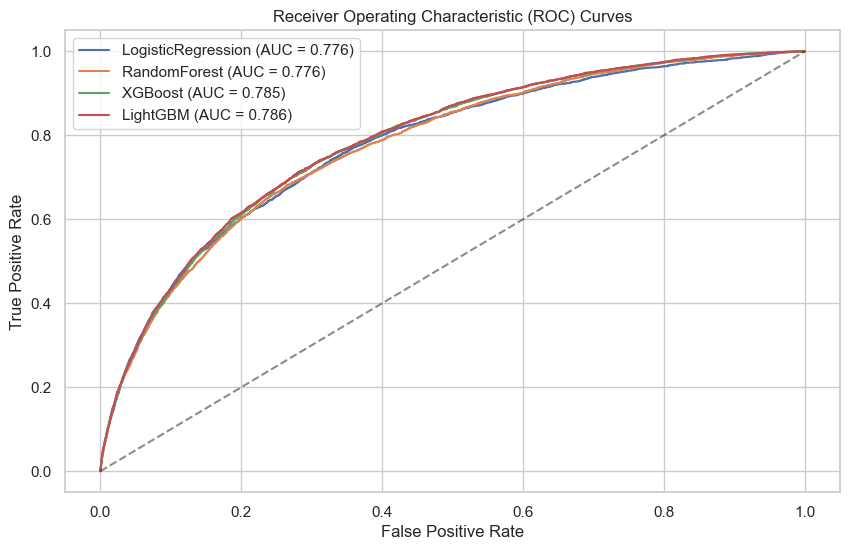

In [8]:
# Plot ROC Curves
plt.figure(figsize=(10, 6))
for model_name, y_pred in results.items():
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

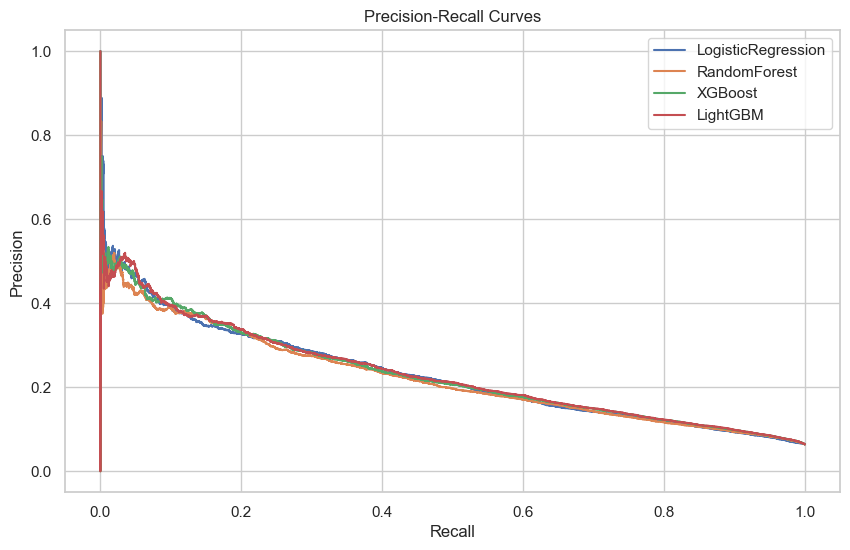

In [9]:
# Plot Precision-Recall Curves
plt.figure(figsize=(10, 6))
for model_name, y_pred in results.items():
    precision, recall, _ = precision_recall_curve(y_test, y_pred)
    plt.plot(recall, precision, label=model_name)
    
plt.title('Precision-Recall Curves')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

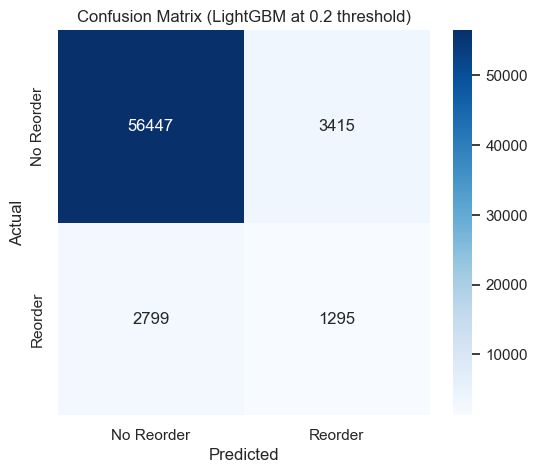

In [10]:
# Confusion Matrix for LightGBM (threshold = 0.2 to account for class imbalance)
y_pred_class = (results['LightGBM'] >= 0.2).astype(int)
cm = confusion_matrix(y_test, y_pred_class)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Reorder', 'Reorder'], yticklabels=['No Reorder', 'Reorder'])
plt.title('Confusion Matrix (LightGBM at 0.2 threshold)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 6. Interpretability & Feature Importance

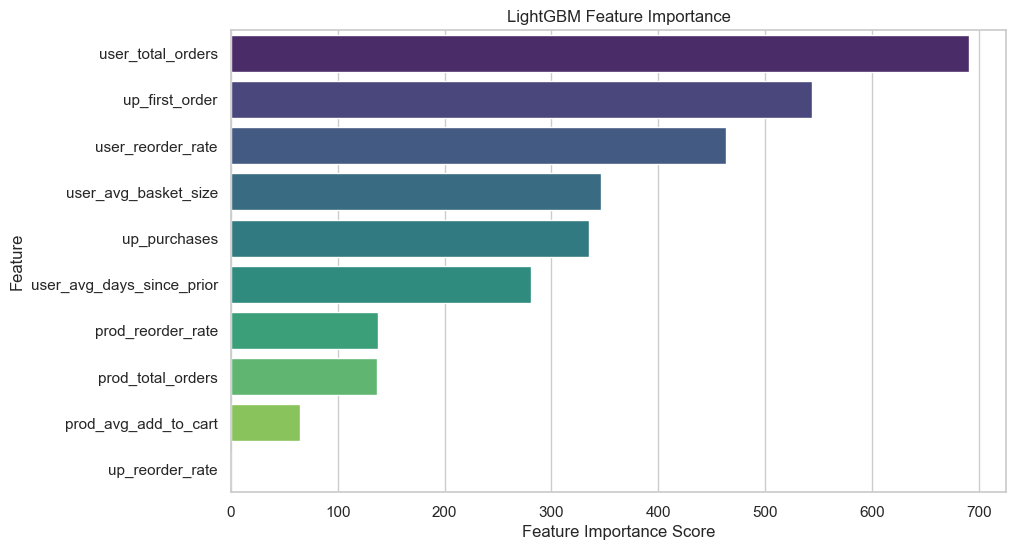

In [11]:
# Plot LightGBM Feature Importance
importances = lgb_model.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('LightGBM Feature Importance')
plt.xlabel('Feature Importance Score')
plt.show()

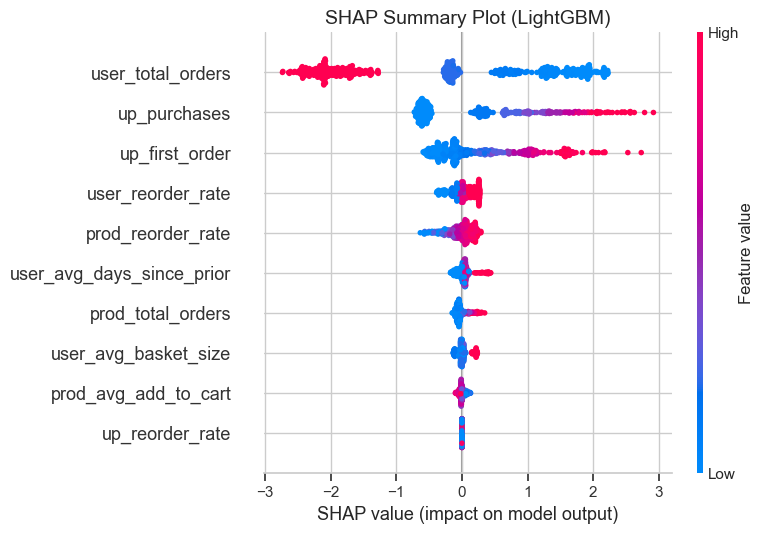

In [12]:
# SHAP Values for LightGBM
import shap

explainer = shap.Explainer(lgb_model, X_train)
# Calculate SHAP values for a sample of 500 test rows
shap_values = explainer(X_test.head(500))

plt.title('SHAP Summary Plot (LightGBM)', fontsize=14)
shap.summary_plot(shap_values, X_test.head(500), show=False)
plt.tight_layout()
plt.show()